# Week 10 - Introduction to Neural Networks: Part II

**Siqi Wang s2823896, Wenhui Yu s2803003, Yichen Zhang s2804697**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with stochastic gradient descent and the role of the learning rate and batch size
>* ways to cope with overfitting, including early stopping, regularization, and dropout
>* incorporating the keras model into an sklearn pipeline

It may be helpful to have last week's notebook open to recall how to build, compile, and fit neural networks in keras.

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

First, we need to install the versions of tensorflow and keras needed for this workshop. The versions in Notable's Machine Learning and Language notebook are older, so anyone using Noteable, should start a Python 3 notebook and then uncomment the lines below to install the correct versions.

In [1]:
!pip install tensorflow==2.20.0
!pip install tf-keras==2.20.1

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 2.1/332.0 MB 14.6 MB/s eta 0:00:23
   ---------------------------------------- 2.1/332.0 MB 14.6 MB/s eta 0:00:23
   ---------------------------------------- 2.1/332.0 MB 14.6 MB/s eta 0:00:23
    --------------------------------------- 4.2/332.0 MB 5.2 MB/s eta 0:01:03
    --------------------------------------- 6.3/332.0 MB 6.4 MB/s eta 0:00:51
   - -------------------------------------- 8.4/332.0 MB 6.8 MB/s eta 0:00:48
   - -------------------------------------- 11.3/332.0 MB 7.8 MB/s eta 0:00:42
   - -------------------------------------- 13.6/332.0 MB 8.3 MB/s eta 0:00:39
   - -------------------------------------- 15.7/332.0 MB 8.6 MB/s eta 0:00:37
   -- ------------------------------------- 17.8/332.0 MB 8.8 MB/s eta 0:00:36
   -- ------------------------------------- 19.9/332.0 MB 9.1 MB/s eta 0:00:35
   -- ------------------------------------- 22.0/332.0 MB 9.0 M


## Packages

Let's load the some of the packages needed for this workshop. 

In [2]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Part 1: Motorcycle Data

In the first part of this workshop, we will work with the motorcyle data, which giving a series of measurements of head acceleration in a simulated motorcycle accident, used to test crash helmets.

This is a small data set with only 1 feature (time) and 1 numerical outcome (head acceleration) recorded at $N=133$ time points, but we will use it illustrate the role of some of parameters in neural networks and gradient descent.


In [3]:
# Load motorcycle data
mcycle = pd.read_csv('mcycle.csv', index_col=0)
N = mcycle.shape[0]
D = mcycle.shape[1]-1
y = mcycle['accel']
X = mcycle.drop('accel', axis=1)
print('Number of observations: ', N)

# Scale the inputs
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X = ss.fit_transform(X)

# Set seed for reproducibility
keras.utils.set_random_seed(11205)

Number of observations:  133


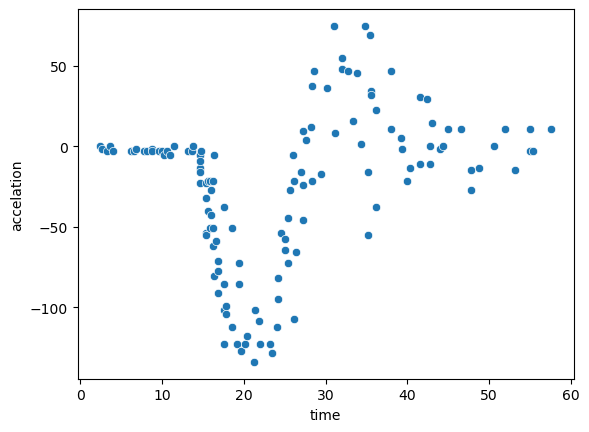

In [4]:
# Plot the data
sns.scatterplot(mcycle, x = 'times', y = 'accel')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 1 (CORE)

Define a neural network in keras with two hidden layers, the first with 20 hidden units and the second with 10 hiddent units, and ReLU activations. You should call your model `model_reg`.

How many parameters does the model have? 

**Note:** since this is a regression task, the final activation should be the identity (`linear` function in keras).

In [5]:
# Code for your answer here!
# Name your model: model_reg

model_reg = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

_The model has a total of 261 parameters._

### Compile the model

Now, let's compile the model. Here, we are using
- the mean squared error loss
- the SGD optimizer
- computing additional metrics, namely R2 and MAE.

In [6]:
model_reg.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

Before, we fit the data, we will first shuffle it. Note the data here is stored in order of time. If we did not first shuffle, the validation would look very different (and consist of the final time points).

In [7]:
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=11205)

### 🚩 Exercise 2 (CORE)

Fit the model with the following options:
- 300 epochs
- batch size equal to $N$ (hint: set the optional parameter `batch_size` in `.fit()`)
- validation set to 10% of the data
- you may also want to set `verbose=0` to avoid printing the output

Plot the metrics as functions of the number of epochs. Comment on their behavior and if you think the model should be trained for more or less epochs.

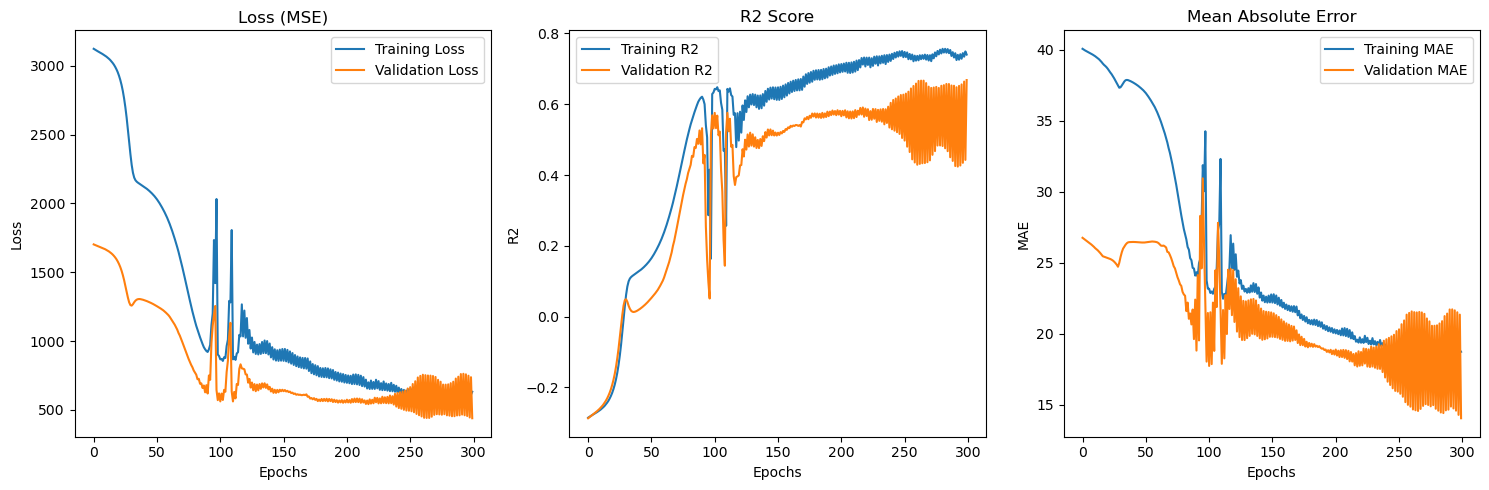

In [8]:
# Code for your answer here!
history = model_reg.fit(
    X, y, 
    epochs=300, 
    batch_size=N, # N is the total number of observations defined earlier
    validation_split=0.1, 
    verbose=0
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['R2'], label='Training R2')
axes[1].plot(history.history['val_R2'], label='Validation R2')
axes[1].set_title('R2 Score')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('R2')
axes[1].legend()

axes[2].plot(history.history['MAE'], label='Training MAE')
axes[2].plot(history.history['val_MAE'], label='Validation MAE')
axes[2].set_title('Mean Absolute Error')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('MAE')
axes[2].legend()

plt.tight_layout()
plt.show()

_For the first ~100 epochs, the model learns quickly, shown by the sharp drop in Loss (MSE) and MAE, and the rapid rise in the R2 score. However, there is a period of severe instability between epochs 100 and 150, where all metrics experience massive spikes. After epoch 150, the training metrics (blue lines) continue to smoothly and steadily improve. In contrast, the validation metrics (orange lines) begin to plateau. By epoch 250, the validation metrics develop severe oscillations (visible as the thick, fuzzy orange bands), meaning the model's performance on unseen data is wildly bouncing around and no longer fundamentally improving.\
The model should be trained for fewer epochs. Because the training metrics keep improving while the validation metrics plateau and become highly unstable, the model has stopped learning generalizable patterns and is beginning to overfit to the training data. The optimizer is likely bouncing around the minimum (which is why the validation line is so thick and noisy at the end). Stopping the training earlier—around epoch 150 to 200, right before those heavy oscillations set in—would result in a more stable and generalizable model._

Let's plot the predictions of the fitted model.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


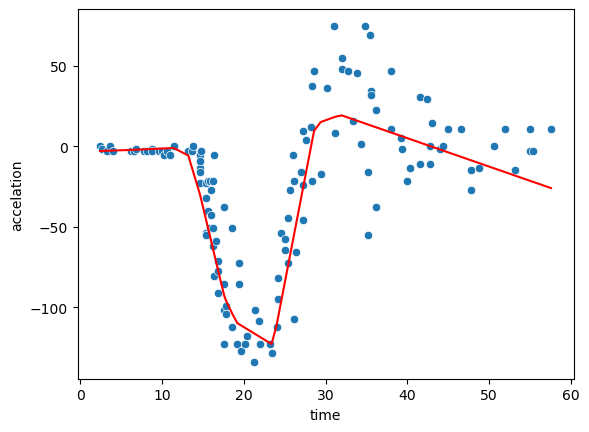

In [9]:
# Compute predictions
yhat = model_reg.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 3 (CORE): Exploring the role of the learning rate

Repeat the above but change the learning rate to 

a) `learning_rate=1e-2` and call this `model_reg2`

b) `learning_rate=1e-4` and call this `model_reg3`

What is the effect of the learning rate?
- Comment on the behavior of the metrics as a function epochs for these choices compared with the previous. 
- Plot also the predictions and comment on they compare with the previous model fit.

*Note:* redefine the model before compiling so that the biases and weights are re-initialized randomly.

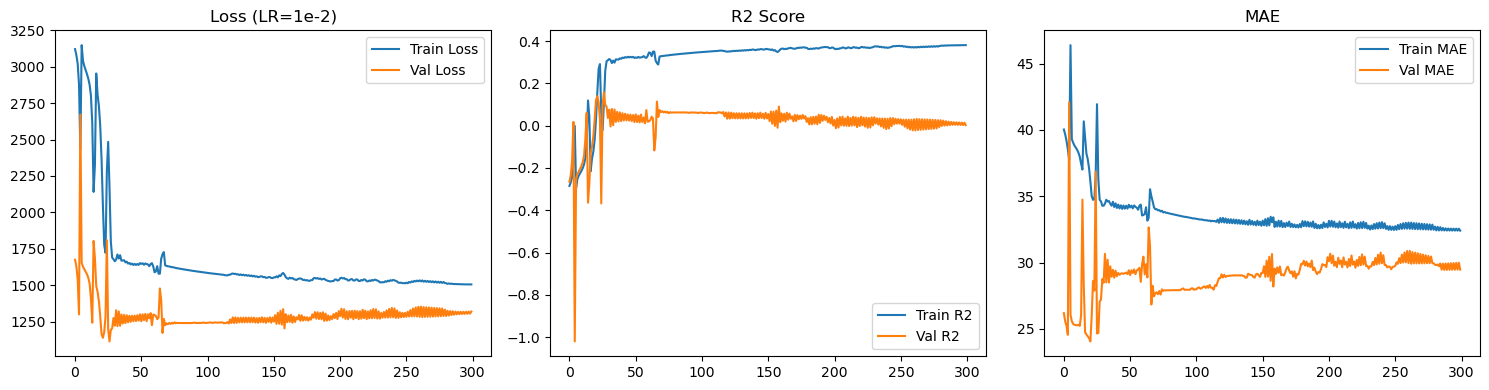

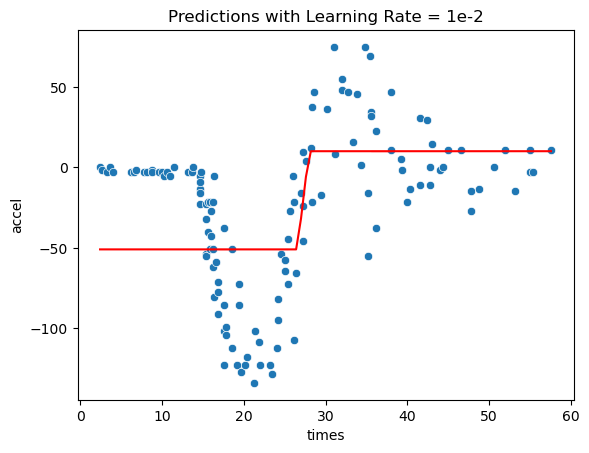

In [10]:
# Option a: larger learning rate

# Code for your answer here!
model_reg2 = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_reg2.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-2),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history2 = model_reg2.fit(X, y, epochs=300, batch_size=N, validation_split=0.1, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history2.history['loss'], label='Train Loss'); axes[0].plot(history2.history['val_loss'], label='Val Loss'); axes[0].set_title('Loss (LR=1e-2)')
axes[1].plot(history2.history['R2'], label='Train R2'); axes[1].plot(history2.history['val_R2'], label='Val R2'); axes[1].set_title('R2 Score')
axes[2].plot(history2.history['MAE'], label='Train MAE'); axes[2].plot(history2.history['val_MAE'], label='Val MAE'); axes[2].set_title('MAE')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

yhat2 = model_reg2.predict(X, verbose=0)
sns.scatterplot(data=mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat2.reshape(-1), color='red')
plt.title('Predictions with Learning Rate = 1e-2')
plt.show()

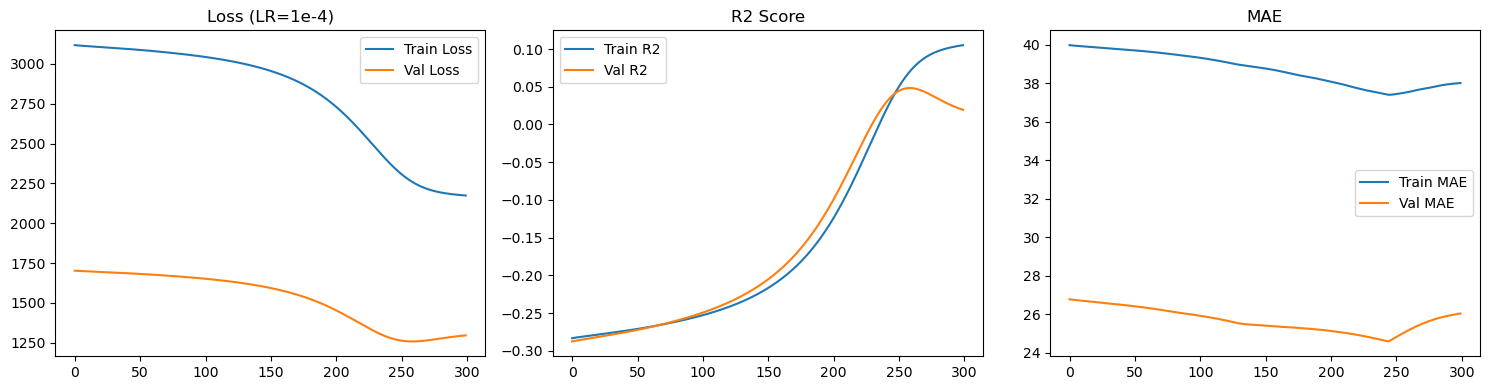

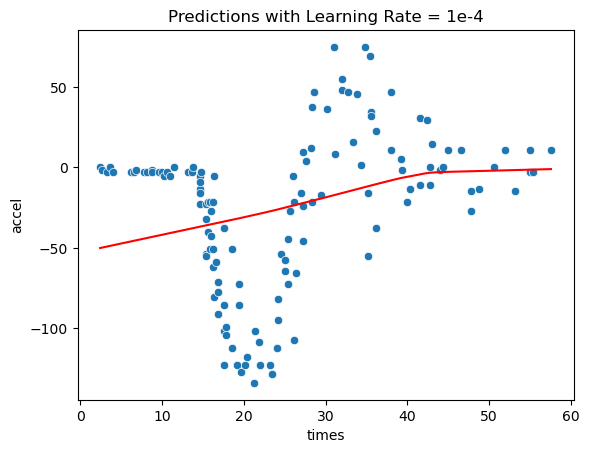

In [11]:
# Option b: smaller learning rate

# Code for your answer here!
model_reg3 = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_reg3.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-4),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history3 = model_reg3.fit(X, y, epochs=300, batch_size=N, validation_split=0.1, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history3.history['loss'], label='Train Loss'); axes[0].plot(history3.history['val_loss'], label='Val Loss'); axes[0].set_title('Loss (LR=1e-4)')
axes[1].plot(history3.history['R2'], label='Train R2'); axes[1].plot(history3.history['val_R2'], label='Val R2'); axes[1].set_title('R2 Score')
axes[2].plot(history3.history['MAE'], label='Train MAE'); axes[2].plot(history3.history['val_MAE'], label='Val MAE'); axes[2].set_title('MAE')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

yhat3 = model_reg3.predict(X, verbose=0)
sns.scatterplot(data=mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat3.reshape(-1), color='red')
plt.title('Predictions with Learning Rate = 1e-4')
plt.show()

_1. Effect on the Metrics (compared to the previous 1e-3 model)
Larger Learning Rate (1e-2): The metrics here are highly unstable and noisy, especially in the first 75 epochs where you see massive, erratic spikes in the Loss and MAE. Because the "steps" the optimizer is taking are too large, it is overshooting the optimal weights and bouncing around the loss landscape. It eventually settles into a sub-optimal state, but the validation metrics remain jittery.\
Smaller Learning Rate (1e-4): The metrics are perfectly smooth but are changing extremely slowly. By the end of the 300 epochs, the loss is still significantly higher (around 2250) compared to the previous model (which dropped below 1000). The optimizer is taking steps that are too tiny, meaning it would need thousands of additional epochs to fully converge.\
2. Effect on the Predictions (compared to the previous 1e-3 model fit)\
Larger Learning Rate (1e-2): The prediction plot looks like a step-function (two flat horizontal lines connected by a sharp jump). It completely fails to capture the smooth "dip" of the data. This often happens with large learning rates when using ReLU activations; the large gradient updates can cause neurons to "die" (output zero permanently), collapsing the model's ability to represent complex curves.\
Smaller Learning Rate (1e-4): The prediction is essentially a straight line with a slight slope. This is a classic example of severe underfitting. Because the learning rate is so small, the model simply hasn't had enough time in 300 epochs to bend and mold itself to the non-linear shape of the motorcycle data.\
The original learning rate of 1e-3 was the "Goldilocks" value for this 300-epoch window—it was small enough to avoid the wild instability and dead neurons of 1e-2, but large enough to actually learn the complex, non-linear curve, unlike the overly sluggish 1e-4 model._

### 🚩 Exercise 4 (CORE): Exploring the effect of the batch size

Previously we used gradient descent (`batch_size=N`). Consider changing the batch size to:

a) `batch_size=20` and call this `model_reg4`

b) `batch_size=1` and call this `model_reg5`

Comment on the effect of the batch size, and your preferred choice.

*Note:* redefine the model before compiling so that the biases and weights are re-initialized randomly.

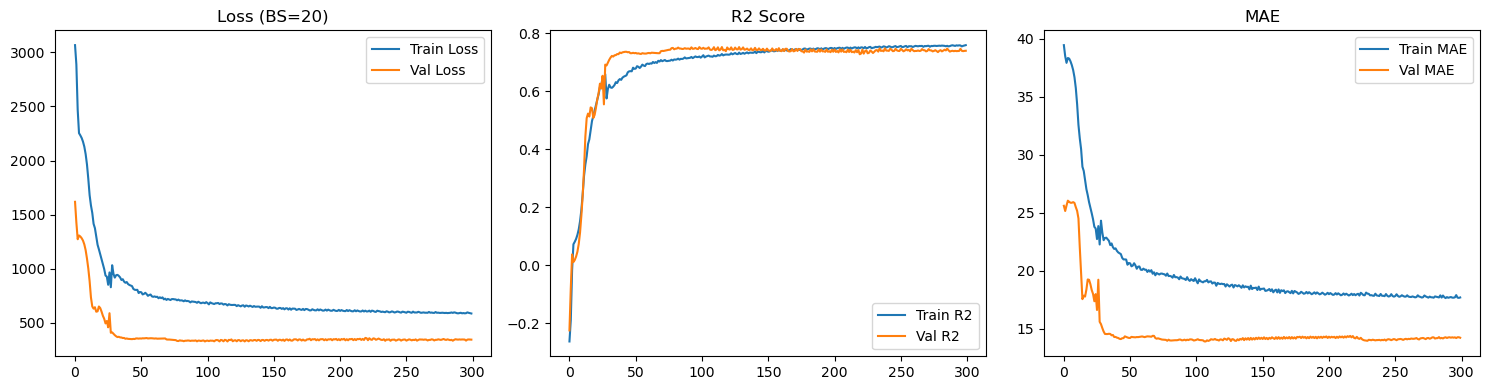

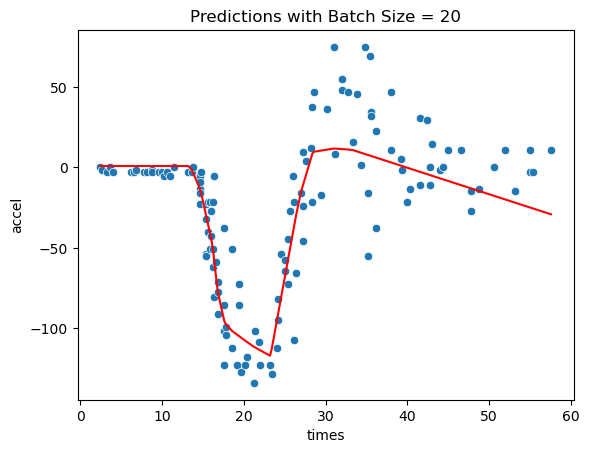

In [12]:
# Option a: batch size of 20

# Code for your answer here!
model_reg4 = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history4 = model_reg4.fit(X, y, epochs=300, batch_size=20, validation_split=0.1, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history4.history['loss'], label='Train Loss'); axes[0].plot(history4.history['val_loss'], label='Val Loss'); axes[0].set_title('Loss (BS=20)')
axes[1].plot(history4.history['R2'], label='Train R2'); axes[1].plot(history4.history['val_R2'], label='Val R2'); axes[1].set_title('R2 Score')
axes[2].plot(history4.history['MAE'], label='Train MAE'); axes[2].plot(history4.history['val_MAE'], label='Val MAE'); axes[2].set_title('MAE')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

yhat4 = model_reg4.predict(X, verbose=0)
sns.scatterplot(data=mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat4.reshape(-1), color='red')
plt.title('Predictions with Batch Size = 20')
plt.show()

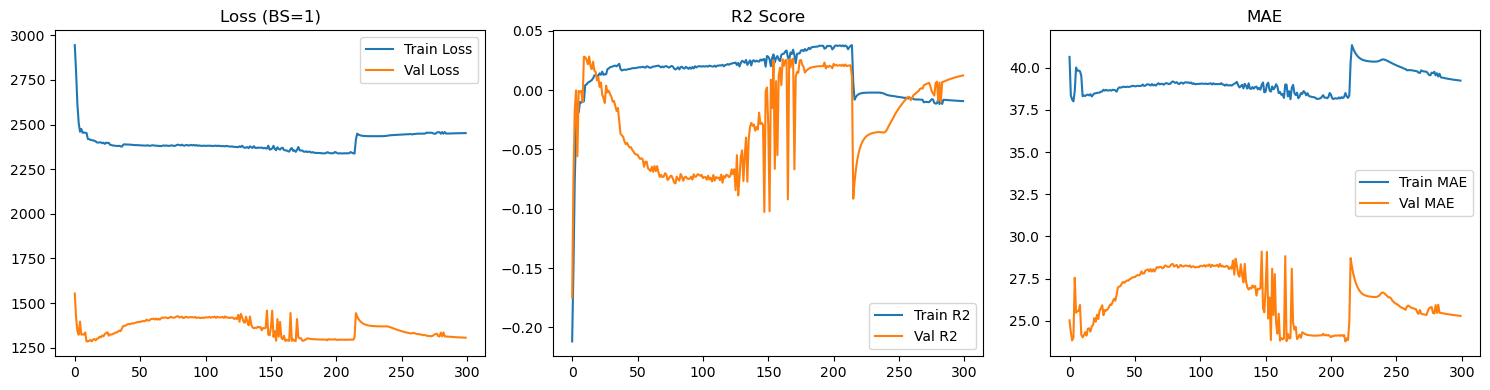

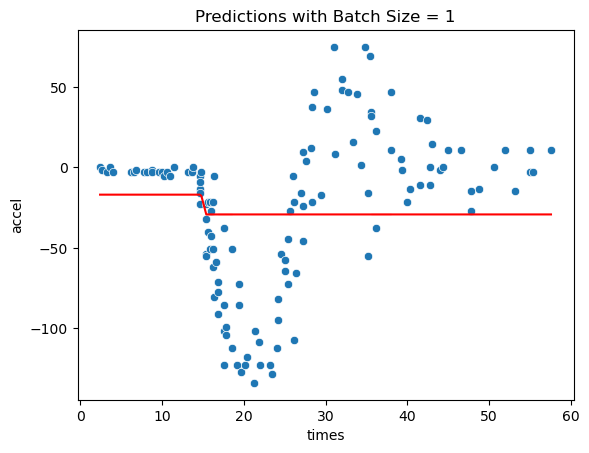

In [13]:
# Option b: batch size of 1

# Code for your answer here!
model_reg5 = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_reg5.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

history5 = model_reg5.fit(X, y, epochs=300, batch_size=1, validation_split=0.1, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history5.history['loss'], label='Train Loss'); axes[0].plot(history5.history['val_loss'], label='Val Loss'); axes[0].set_title('Loss (BS=1)')
axes[1].plot(history5.history['R2'], label='Train R2'); axes[1].plot(history5.history['val_R2'], label='Val R2'); axes[1].set_title('R2 Score')
axes[2].plot(history5.history['MAE'], label='Train MAE'); axes[2].plot(history5.history['val_MAE'], label='Val MAE'); axes[2].set_title('MAE')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

yhat5 = model_reg5.predict(X, verbose=0)
sns.scatterplot(data=mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat5.reshape(-1), color='red')
plt.title('Predictions with Batch Size = 1')
plt.show()

_The Effect of Batch Size\
Batch Size = 20 (Mini-Batch Gradient Descent): This batch size strikes an excellent balance. Because it updates the weights several times per epoch (unlike full batch, which updates only once), the model learns much faster, reaching a low loss and a high R2 score very quickly. Furthermore, because it averages the gradient over 20 points for each update, it smooths out the noise of individual data points. The result is a highly stable training curve and a prediction line that beautifully captures the non-linear "dip" in the motorcycle data.\
Batch Size = 1 (Pure Stochastic Gradient Descent): This batch size results in chaotic and erratic learning. Because the model updates its weights based on a single data point at a time, it is highly sensitive to noise and outliers. You can see this in the extreme, jagged spikes in the R2 and MAE plots, and the sudden jumps in the loss curve. The optimizer is being bounced around so violently that it fails to converge on a good solution, ultimately collapsing into a simple step-function that completely misses the shape of the data.\
My preferred choice is absolutely batch_size=20. It provides the best of both worlds: the faster learning speed of smaller batches, combined with the gradient stability needed to successfully fit the complex curve without collapsing or oscillating wildly like the batch_size=1 model._

### Early stopping

When using minibatches, SGD converges much faster and 300 epochs seems unnecessary. We can use keras's [EarlyStopping](https://keras.io/api/callbacks/early_stopping/) to exit early. In this case, we need to decide:
- the metric to monitor (`monitor`)
- the minimum change in the monitored quantity to qualify as an improvement (`min_delta`)
- the number of epochs with no improvement after which training will be stopped (`patience`)

In the following, we use early stopping to avoid training for the full 300 epochs.

In [14]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg4 = keras.models.Model(input_layer, output_layer)

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

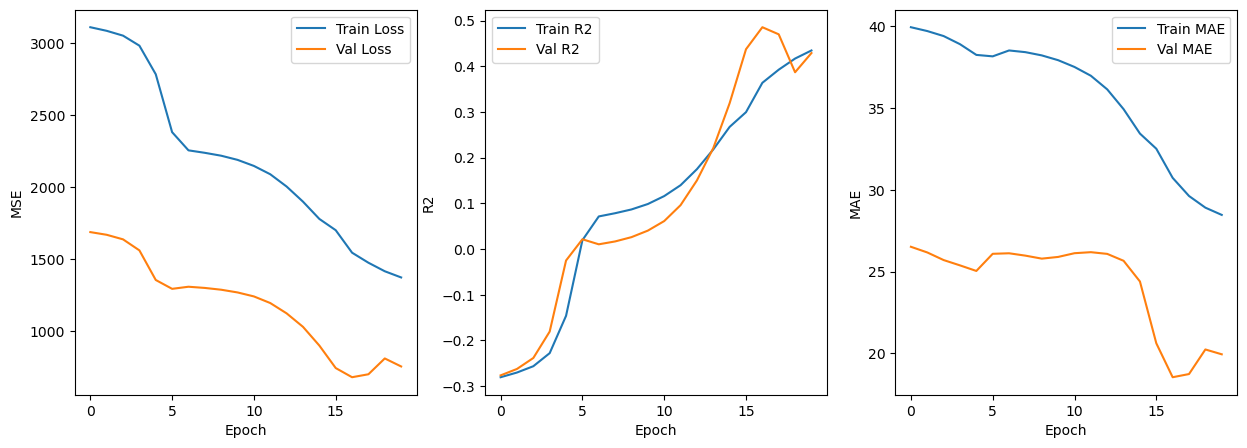

In [15]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta = 0, mode = 'min', 
                                         patience=3, restore_best_weights=True)

model_reg4.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20, callbacks=[callback])

# Plot the training history
history = model_reg4.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


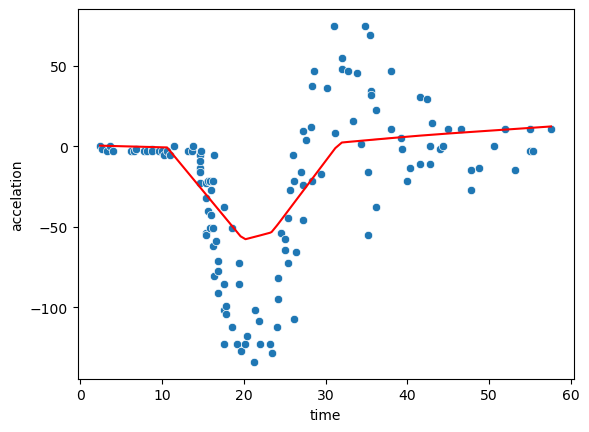

In [16]:
# Compute predictions
yhat = model_reg4.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

But, it seems that it has stopped too early!

### 🚩 Exercise 5 (CORE)

Try changing any or all of the three parameters determining the early stopping criteria. What have you decided and why? How has it changed the number of epochs before exiting?

Training stopped after 67 epochs.


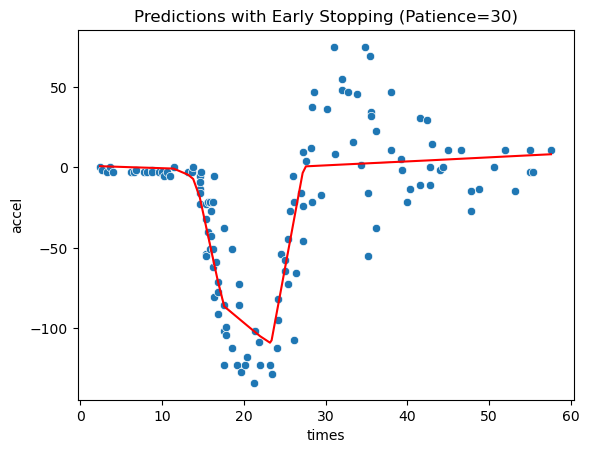

In [17]:
# Code for your answer here!
model_reg6 = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_reg6.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[keras.metrics.R2Score(name='R2'), keras.metrics.MeanAbsoluteError(name='MAE')]
)

new_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    min_delta=0, 
    mode='min', 
    patience=30,
    restore_best_weights=True
)

history6 = model_reg6.fit(
    X, y, 
    epochs=300, 
    shuffle=True, 
    validation_split=0.1, 
    verbose=0, 
    batch_size=20, 
    callbacks=[new_callback]
)

num_epochs = len(history6.history['loss'])
print(f"Training stopped after {num_epochs} epochs.")

yhat6 = model_reg6.predict(X, verbose=0)
sns.scatterplot(data=mcycle, x='times', y='accel')
sns.lineplot(x=ss.inverse_transform(X).reshape(-1), y=yhat6.reshape(-1), color='red')
plt.title(f'Predictions with Early Stopping (Patience=30)')
plt.show()

_I decided to increase the patience parameter from 3 to 30. Because we are using mini-batch gradient descent (batch_size=20), the validation loss curve is inherently noisy and will naturally fluctuate up and down slightly from epoch to epoch. With a patience of only 3, the training was prematurely aborted during one of these normal, temporary spikes in validation loss. Increasing the patience to 30 gives the EarlyStopping callback enough leniency to ride out those short-term fluctuations and wait to see if the model actually resumes improving.\
Increasing the patience significantly increased the number of epochs the model ran before exiting. Instead of stopping prematurely around epoch 15-20, the model was allowed to run much longer. As shown in the new plot, this extra training time allowed the model to actually learn the complex, non-linear shape of the data, resulting in a prediction line that successfully captures the deep "dip" in acceleration instead of severely underfitting it._

### 🚩 Exercise 6 (EXTRA)

For comparison, let's fit kernel ridge regression model with radial basis function. 

- Try changing the value of gamma in the code below. How does it effect the regression function?
- Try changing the value of alpha in the code below. How does it effect the regression function?
- Comment on which model you prefer (neural network or kernel ridge) both in terms of predictive performance and ease of implementation.

In [ ]:
from sklearn.kernel_ridge import KernelRidge

# Define and fit the model
kr = KernelRidge(alpha = 0.1, kernel='rbf', gamma=4).fit(X,y)

# Compute predictions
yhat = kr.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat, c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

_Type your answer here_

### Heteroskedastic regression with a custom loss

Our previous model only provided an estimate of the mean function for acceleration as a function of time. However, visually, it is evident that the variance of acceleration also varies with time. 

Let's define a custom loss function for the case of heteroskedastic regression. In this case, the loss corresponds to the negative log likelihood of the Gaussian with unknown mean and standard deviation (see Lecture 9 Notes). Here, our neural network model will output both the mean and standard deviation, we have concantenated them together to output an matrix with two columns (the first for the mean, and the second for the standard deviation).

In [ ]:
# Gaussian NLL as a custom loss 
def my_loss(y_true, y_pred):   
    mu_pred = y_pred[:, 0]
    sigma_pred = y_pred[:, 1]  
    y_true = tf.cast(y_true, mu_pred.dtype)    
    y_true = tf.reshape(y_true, tf.shape(mu_pred))   

    # NLL (up to a constant): 0.5 * ((y - mu)/sigma)^2 + log(sigma)    
    sq_term = 0.5 * tf.square((y_true - mu_pred) / sigma_pred)    
    log_term = tf.math.log(sigma_pred)    
    nll = sq_term + log_term    
    
    # Reduce mean over batch    
    return tf.reduce_mean(nll)

Now, let's start with a simple model for illustration. We will keep the same architecture for the mean, but for the standard deviation, for simplicity, we assume no hidden layer (it depends only on the inputs directly, i.e. subject to the nonlinear activation, there is a linear relation between time and the standard deviation of acceleration).

For the ouput of the standard deviaton, we use the `softplus` activation to ensure that it is positive. 

In [ ]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_mean = keras.layers.Dense(1, activation='linear') (hidden_layer2)
output_sigma = keras.layers.Dense(1, activation='softplus') (input_layer)
stack = keras.layers.Concatenate()([output_mean, output_sigma])
model_reg_het = keras.Model(input_layer, stack)

model_reg_het.compile(
    loss=my_loss,
    optimizer= keras.optimizers.SGD(learning_rate=0.001),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

### 🚩 Exercise 7 (CORE)

Train the model for as many epochs as needed (when early stopping exits), and plot the mean function, also with lines for +/- 2*standard deviation, overlaid on top of a scatterplot of the data.

How does the model perform?

_Note: if it exits without training, re-initialize by running the code cell above again._

In [ ]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='loss', min_delta = 0.05, mode ='min', 
                                         patience=10, restore_best_weights=True)

# Code for your answer here!

_Type your answer here_

### Regularization

The heteroskedastic model performs quite poor, explaining most of the variation in the data as noise. Since the noise term is too large, we can try to include regularization to shrink the weights and bias of the layer that models the standard deviation. In this case, we want to shrink the weights AND bias, as the bias controls the overall level of variance, which is estimated to be large in our previous model.

In this, case when defining our activation function `keras.layers.Dense`, we will use the options:
- `bias_regularizer`
- `kernel_regularizer`

Available regularizers are provided in: https://keras.io/api/layers/regularizers/

### 🚩 Exercise 8 (CORE)

Modify your previous model to include $L_2$ regularization for `output_sigma` layer. Use a penalty parameter of 1.0 for the bias and 0.01 for the weights.

Train the model for as many epochs as needed (when early stopping exits), and plot the mean function, also with lines for +/- 2*standard deviation, overlaid on top of a scatterplot of the data.

How does the model perform?

_Note: if trained long enough, you should reach an R2 around 0.2 on the training data. If it stops before then, it has been initialized poorly and you should rerun the initial model definition to reinitialize with the weights and biases._

In [ ]:
# Defining the model with regularization

In [ ]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='loss', min_delta = 0.05, mode = 'min', 
                                         patience=10, restore_best_weights=True)



In [ ]:
# Compute predictions and plot

_Type your answer here_

When can of course tune and tweak the model further to try to get better performance. This can take some time. Instead, we will look at another dataset to understand how to wrap our keras model into sklearn's pipeline.

# Part 2: Hitters Data

In the second part of this workshop, we will work with the hitters data, which was used in the Introduction to Statistical Learning (2023). The data records a number of statistics and salaries for baseball players. We wish to predict a baseball player's salary on the basis of various statistics
associated with performance in the previous year.

In this part of the workshop, we will understand how to wrap our keras model into sklearn's pipeline to include our feature engineering steps.

Let's start by loading the data and looking at some basic information to understand what feature engineering steps are needed.

In [ ]:
hitters = pd.read_csv('Hitters.csv')

In [ ]:
hitters.head()

In [ ]:
hitters.info()

There are 20 variables in total, with 3 of them being of type object. We will need to do some encoding of these features. 

We see that there are some missing values in salaries of players. Since this is our target variables, we will drop these missing values. Although it would be interesting to check if those who are missing salaries have different characteristics in terms of their features (_not pursued here_); this might signal an informative missing mechanism and that our predictive model may only be applicable to a subpopulation of baseball players. 

In [ ]:
# Remove observations with missing target variable
hitters = hitters.dropna()
N = hitters.shape[0]
D = hitters.shape[1]-1
print('Number of observations:', N)
print('Number of features:', D)

For the pairplot below, we observe high correlation among some of the features.  Also since the numeric variables are on very different scales, we need to do some feature scaling. 

In [ ]:
sns.pairplot(hitters, corner=True, diag_kind='hist', hue = 'League')
plt.show()

Checking the distribution of the categorical features, we see that they are all binary variables and there are no rare categories.

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (12,4))
sns.countplot(hitters, x='League', ax =ax[0])
sns.countplot(hitters, x='Division', ax =ax[1])
sns.countplot(hitters, x='NewLeague', ax =ax[2])
plt.show()

Before we define our model, let's start by splitting into a training and test set.

In [ ]:
from sklearn.model_selection import train_test_split
y = hitters['Salary']
X = hitters.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

We are now ready to define our feature engineering steps to be used in our model pipeline. We will use standard scaling for the numerical variables and one hot encoding for the binary features.

In [ ]:
# Feature engineering steps
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Names of numeric features
num_features = X_train.columns[X_train.dtypes=='int64']
# Names of categorical features
cat_features = X_train.columns[X_train.dtypes=='object']

preprocessor = make_column_transformer(
    (StandardScaler(), num_features),
    (OneHotEncoder(drop='first'),cat_features),
    verbose_feature_names_out=False
)

### Baseline linear regression

We start by fitting a baseline linear regression model and investigating performance on the test data.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

lm = make_pipeline(
    preprocessor,
    LinearRegression()
).fit(X_train, y_train)

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

yhat_test = lm.predict(X_test)
print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

The R2 is relatively low, but an advantage of the linear regression model is that we can examine the coefficients to understand the effect of the different features.

In [ ]:
coefs = pd.DataFrame({'feature': lm[:-1].get_feature_names_out(), 
                      'coef': lm[-1].coef_}).sort_values ("coef", ascending=False)
coefs
sns.barplot(coefs, y= 'feature', x = 'coef')
plt.show()

### Wrapping keras model into an sklearn regression model

Our first step to turn our keras model into an sklearn regressor is to define the neural network model. We define a general MLP that can be constructed by passing in the desired number of neurons in each layer.

In [ ]:
def mlp_model(X, y, lr = 0.001, layers=[64]):
    # Creates a basic MLP model 
    D = X.shape[1]
    input_layer = keras.layers.Input(shape=(D,))

    hidden_layer = input_layer
    for layer_width in layers:
        hidden_layer = keras.layers.Dense(layer_width, activation="relu")(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer)

    model = keras.Model(input_layer, output_layer)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr),
                  metrics=[keras.metrics.R2Score(name='R2')])

    return model

Next, we simply use keras's sklearn wrappers: https://keras.io/api/utils/sklearn_wrappers/ 

This allows us to turn our keras model into an sklearn model. Through `model_kwargs`, we can specify the arguments of our `mlp_model` and through `fit_kwargs`, we can specify the arguments that we usually pass into keras's `.fit()`.

In [ ]:
from keras.wrappers import SKLearnRegressor

nn = SKLearnRegressor(
    model=mlp_model,
    model_kwargs={
        "layers": [64],
    },
    fit_kwargs={
        "epochs": 1000, 
        "shuffle": True, 
        "verbose": 0, 
        "batch_size": 20, 
        "callbacks": [keras.callbacks.EarlyStopping(monitor='R2', min_delta = 0.001, mode = 'max', 
                                                    patience=5, restore_best_weights=True)]
    }
)

Now, that is a sklearn model, we can simply use pipelines to combine the preprocessing steps with our estimator!

In [ ]:
nn_pip = make_pipeline(
    preprocessor,
    nn
).fit(X_train, y_train)

Let's plot the history to check that we have trained the model for long enough.

In [ ]:
# Plot the training history
history =nn_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(history['R2'], label='Train R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
plt.show()

Finally, let's check the performance of our model.

In [ ]:
yhat_test = nn_pip.predict(X_test)

print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

The performance is better than the linear model!

### 🚩 Exercise 9 (CORE)

Try training a deeper model, with your choice of depth and width.

How does the model perform?

In [ ]:
# Code for your answer here!

_Type your answer here_

### 🚩 Exercise 10 (CORE)

Define a new MLP model, by altering the previous model to include $L_1$ regularization. You should define your model so that you can pass in different penalty parameters for each layer. 

Now train you deeper model from Exercise 9, but with $L_1$ regularization for your choice of penalty parameters.

How does the model perform?

In [ ]:
# Code for your answer here

_Type your answer here_

### 🚩 Exercise 11 (EXTRA)

Define a new MLP model, but instead of using $L_1$ regularization, use dropout to help avoid overfitting. After defining each hidden layer, you need to add another line in your model, including a `keras.layers.Dropout` layer, see https://keras.io/api/layers/regularization_layers/dropout/

You should define your model so that you can pass in different dropout rates for each layer. 

Now train you deeper model from Exercise 9, but with dropout for your choice of rates.

How does the model perform?

In [ ]:
# Code for your answer here

_Type your answer here_

# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
!jupyter nbconvert --to pdf mlp_week10.ipynb 